In [15]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

df= pd.read_csv("../data/ai_job_dataset.csv")
df

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,AI14996,Robotics Engineer,38604,USD,EN,FL,Finland,S,Finland,50,"Java, Kubernetes, Azure",Bachelor,1,Energy,2025-02-06,2025-03-25,1635,7.9,Advanced Robotics
14996,AI14997,Machine Learning Researcher,57811,GBP,EN,CT,United Kingdom,M,United Kingdom,0,"Mathematics, Docker, SQL, Deep Learning",Master,0,Government,2024-10-16,2024-10-30,1624,8.2,Smart Analytics
14997,AI14998,NLP Engineer,189490,USD,EX,CT,South Korea,L,South Korea,50,"Scala, Spark, NLP",Associate,17,Manufacturing,2024-03-19,2024-05-02,1336,7.4,AI Innovations
14998,AI14999,Head of AI,79461,EUR,EN,FT,Netherlands,M,Netherlands,0,"Java, Computer Vision, Python, TensorFlow",PhD,1,Real Estate,2024-03-22,2024-04-23,1935,5.6,Smart Analytics


# 3) Comparer des groupes
## 3.1) Boxplot

Index(['Retail', 'Media', 'Automotive', 'Consulting'], dtype='object', name='industry')


Text(0.5, 1.05, "Comparaison des salaires selon le niveau d'experiance, l'industruie et la taille de l'entreprise\nBoxplot")

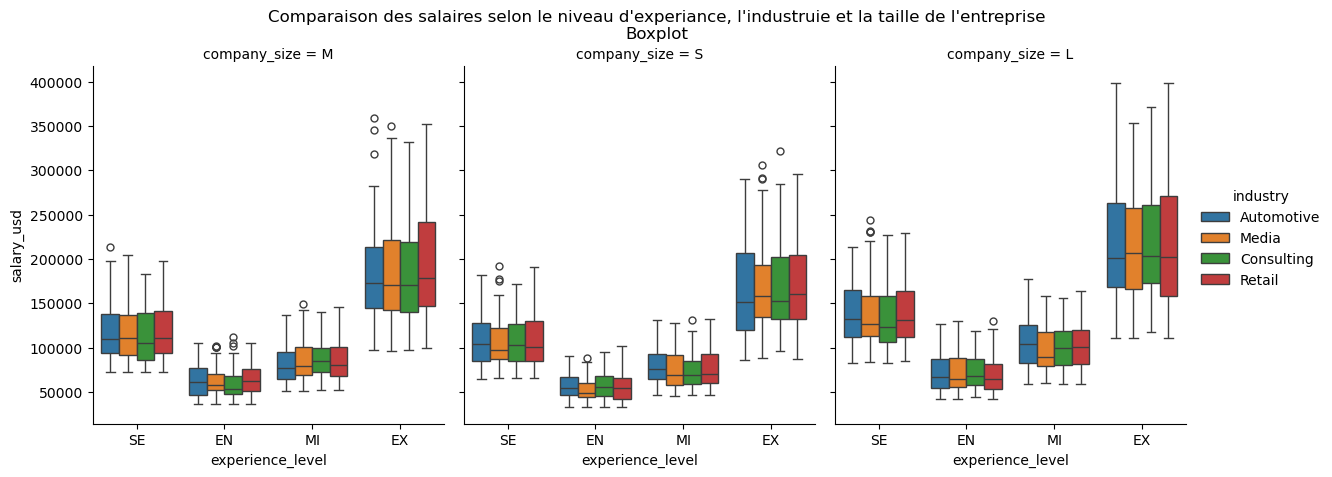

In [16]:
top_industries = df['industry'].value_counts().nlargest(4).index #les 4 industries les plus frequentes
print(top_industries)
df_filtered = df[df['industry'].isin(top_industries)]
f = sns.catplot(
    data=df_filtered,   
    x="experience_level",
    y="salary_usd",
    hue="industry",
    col="company_size",   
    kind="box",
    height=4.5,
    aspect=0.9
)
f.fig.suptitle("Comparaison des salaires selon le niveau d'experiance, l'industruie et la taille de l'entreprise\nBoxplot", y=1.05)

### Interpretation et analyse:
Ce boxplot illustre que les salaires augmentent avec le niveau d’expérience et la taille de l’entreprise, car les profils plus expérimentés apportent davantage de valeur ajoutée et les grandes structures disposent de moyens financiers plus importants pour rémunérer leurs employés. Les différences entre industries traduisent la nature économique de chaque secteur : certains génèrent plus de revenus ou nécessitent des compétences spécialisées, ce qui se reflète dans des salaires plus élevés, tandis que d’autres restent plus modestes. La dispersion observée dans les boxplots montre aussi que, même au sein d’un même niveau d’expérience ou d’une même industrie, les salaires varient selon des facteurs comme la spécialisation, la localisation ou la rareté des compétences. En somme, les résultats s’expliquent par la combinaison de l’expérience, de la taille de l’entreprise et de la dynamique propre à chaque secteur.

## 3.2) Violin plot

Text(0.5, 1.05, "Comparaison des salaires selon le niveau d'experiance, l'industruie et la taille de l'entreprise\nviolin plot")

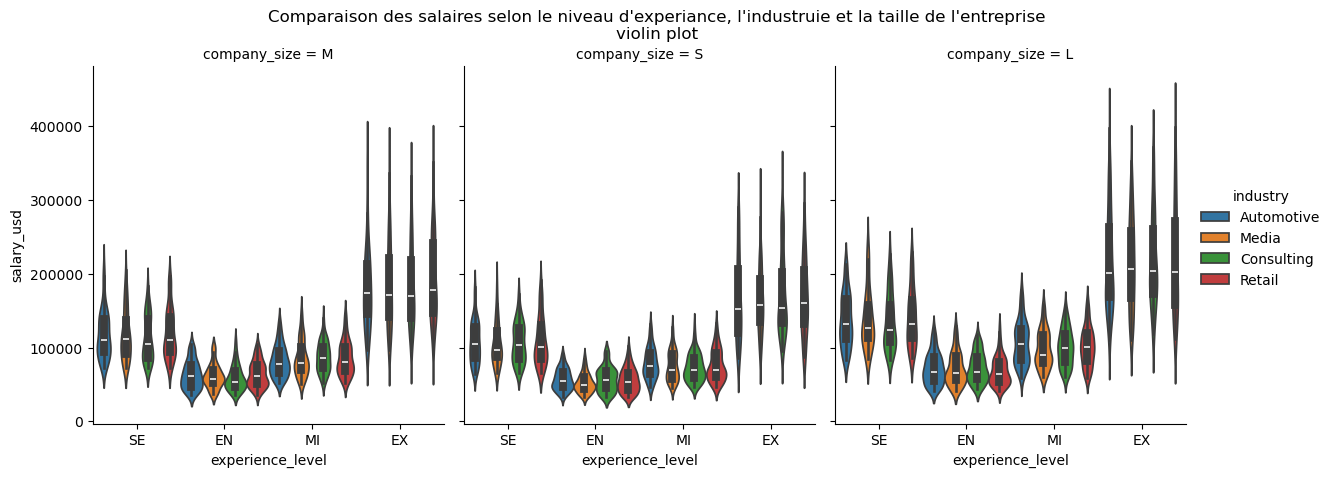

In [17]:
f = sns.catplot(
    data=df_filtered,   
    x="experience_level",
    y="salary_usd",
    hue="industry",
    col="company_size",   
    kind="violin",
    height=4.5,
    aspect=0.9,
    width=1
)

f.fig.suptitle("Comparaison des salaires selon le niveau d'experiance, l'industruie et la taille de l'entreprise\nviolin plot", y=1.05)

### Interpretation et analyse:
Ce violon plot illustre la distribution des salaires en fonction du niveau d’expérience, de l’industrie et de la taille de l’entreprise. On remarque que les salaires tendent à croître avec l’expérience, en particulier pour les profils MI et EX, et que les grandes entreprises (L) présentent des distributions plus étendues et des médianes plus élevées que les petites (S) ou moyennes (M). Les formes des violons montrent aussi la densité des salaires : certaines industries concentrent davantage de valeurs autour de niveaux spécifiques, tandis que d’autres affichent une dispersion plus large. Ces résultats s’expliquent par le fait que l’expérience accroît la valeur des employés, que les grandes entreprises disposent de plus de moyens financiers, et que chaque secteur a ses propres dynamiques économiques, ce qui crée des écarts de rémunération et des distributions distinctes.
## 3.3) les decisions
À partir des deux graphes (boxplot et violon plot), plusieurs décisions peuvent être dégagées. D’abord, il est clair que l’expérience est le facteur le plus déterminant : les profils MI et surtout EX obtiennent des salaires nettement supérieurs, ce qui justifie d’investir dans la formation et la montée en compétences des employés. Ensuite, la taille de l’entreprise influence fortement la rémunération : les grandes entreprises (L) offrent non seulement des salaires plus élevés mais aussi une plus grande variabilité, ce qui traduit davantage d’opportunités et de marges de négociation. Enfin, les industries présentent des comportements distincts, certaines concentrant les salaires autour de valeurs spécifiques, d’autres montrant une dispersion plus large, ce qui suggère que le choix du secteur est stratégique pour maximiser ses perspectives salariales. En résumé, les résultats orientent vers trois décisions clés : valoriser l’expérience, cibler les grandes entreprises pour une meilleure rémunération, et choisir l’industrie en fonction de ses objectifs financiers et professionnels.
